# bench-tabular-climate — 12-Month-Ahead Global Temperature Anomaly Forecast

A challenging tabular regression use case around climate change: predict the
**global mean surface temperature anomaly 12 months ahead** from public monthly
climate records. The test period (2015 onwards) is warmer than anything in the
training range, so this is fundamentally an **extrapolation-under-trend**
problem, exactly the regime where tree ensembles are known to saturate and
models that can represent trends (linear terms, in-context learners) have a
structural chance.

Ingredients:
- **Data (three public tables, joined on year/month)**:
  - NASA GISTEMP v4 monthly land-ocean anomalies, global + NH + SH
    (`data.giss.nasa.gov`),
  - NOAA Mauna Loa monthly CO2 (`gml.noaa.gov`),
  - NOAA Oceanic Nino Index (ENSO state, `psl.noaa.gov`).
- **Preprocessing**: [skrub](https://skrub-data.org) `TableVectorizer` +
  `DatetimeEncoder` on the assembled feature frame, fitted on train only.
- **Models**: ridge, random forest, XGBoost, LightGBM, CatBoost, torch MLP,
  **TabICLv2** regressor (quantile-based, arXiv:2602.11139) and Google
  **TabFM** regressor (zero-shot in-context learning), plus a persistence
  baseline (anomaly stays at today's value).
- **Protocol**: chronological split, train to 2004, validation 2005-2014,
  test 2015-present. The 12-month target horizon means the last 12 months of
  each segment cannot leak into the next; a 12-month purge gap enforces this.
- **Tracking**: one Weights & Biases run per model via `utils.wandb_utils`.


## 1. Setup


In [1]:
import os, subprocess, sys
from pathlib import Path

cwd = Path.cwd()
repo_root = cwd.parent if cwd.name == "ml_pipeline" else cwd
if (repo_root / "ml_pipeline").is_dir() and (repo_root / "requirements.txt").is_file():
    os.chdir(repo_root)
    print(f"Using local checkout: {repo_root}")
else:
    subprocess.run(["rm", "-rf", "bench_research_ml_project"], check=True)
    subprocess.run(["git", "clone", "https://github.com/oremaz/bench_research_ml_project"], check=True)
    os.chdir("bench_research_ml_project")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

if Path.cwd().name != "ml_pipeline":
    os.chdir("ml_pipeline")
print(f"Working directory: {Path.cwd()}")


Using local checkout: /scratch/omazor/bench_research_ml_project
Working directory: /scratch/omazor/bench_research_ml_project/ml_pipeline


In [2]:
import urllib.request

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from pipelines_torch.models import MODEL_REGISTRY
from pipelines_torch.base import GeneralPipeline
from utils.wandb_utils import init_wandb_run, log_summary, finish_run

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

WANDB_PROJECT = "bench-research-ml"

CLIMATE_DIR = Path("data/climate")
CLIMATE_DIR.mkdir(parents=True, exist_ok=True)

SOURCES = {
    "gistemp_glb.csv": "https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv",
    "gistemp_nh.csv": "https://data.giss.nasa.gov/gistemp/tabledata_v4/NH.Ts+dSST.csv",
    "gistemp_sh.csv": "https://data.giss.nasa.gov/gistemp/tabledata_v4/SH.Ts+dSST.csv",
    "co2_mm_mlo.csv": "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv",
    "oni.data": "https://psl.noaa.gov/data/correlation/oni.data",
}
for fname, url in SOURCES.items():
    target = CLIMATE_DIR / fname
    if not target.exists():
        print("Downloading", fname)
        urllib.request.urlretrieve(url, target)
print("Climate tables ready:", sorted(p.name for p in CLIMATE_DIR.iterdir()))


Device: cuda
Climate tables ready: ['co2_mm_mlo.csv', 'gistemp_glb.csv', 'gistemp_nh.csv', 'gistemp_sh.csv', 'oni.data']


## 2. Parse and join the three sources
Everything is joined on (year, month) into one monthly frame from March 1958
(start of the Mauna Loa record).


In [3]:
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def read_gistemp(path, value_name):
    df = pd.read_csv(path, skiprows=1)
    df = df[["Year"] + MONTHS].melt(id_vars="Year", var_name="month_name", value_name=value_name)
    df["month"] = df["month_name"].map({m: i + 1 for i, m in enumerate(MONTHS)})
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return df.rename(columns={"Year": "year"})[["year", "month", value_name]]

glb = read_gistemp(CLIMATE_DIR / "gistemp_glb.csv", "anom_glb")
nh = read_gistemp(CLIMATE_DIR / "gistemp_nh.csv", "anom_nh")
sh = read_gistemp(CLIMATE_DIR / "gistemp_sh.csv", "anom_sh")

co2 = pd.read_csv(CLIMATE_DIR / "co2_mm_mlo.csv", comment="#")
co2 = co2.rename(columns={"deseasonalized": "co2_trend"})[["year", "month", "average", "co2_trend"]]
co2 = co2.rename(columns={"average": "co2"})
co2.loc[co2["co2"] < 0, "co2"] = np.nan

oni_rows = []
for line in (CLIMATE_DIR / "oni.data").read_text().splitlines():
    parts = line.split()
    if len(parts) == 13 and parts[0].isdigit() and 1900 < int(parts[0]) < 2100:
        year = int(parts[0])
        for m, v in enumerate(parts[1:], start=1):
            val = float(v)
            oni_rows.append({"year": year, "month": m, "oni": np.nan if val < -90 else val})
oni = pd.DataFrame(oni_rows)

clim = (glb.merge(nh, on=["year", "month"]).merge(sh, on=["year", "month"])
           .merge(co2, on=["year", "month"], how="left").merge(oni, on=["year", "month"], how="left"))
clim["date"] = pd.to_datetime(dict(year=clim["year"], month=clim["month"], day=1))
clim = clim.sort_values("date").reset_index(drop=True)
clim = clim[(clim["date"] >= "1958-03-01")].dropna(subset=["anom_glb", "co2", "oni"]).reset_index(drop=True)
print(f"Joined monthly record: {len(clim)} rows, {clim['date'].min().date()} -> {clim['date'].max().date()}")
clim.tail(3)


Joined monthly record: 819 rows, 1958-03-01 -> 2026-05-01


,year,month,anom_glb,anom_nh,anom_sh,co2,co2_trend,oni,date
816,2026,3,1.32,1.62,1.02,430.15,428.70,0.13,2026-03-01
817,2026,4,1.17,1.40,0.95,431.12,428.61,0.51,2026-04-01
818,2026,5,1.13,1.30,0.97,432.34,429.10,0.98,2026-05-01


## 3. Features and 12-month-ahead target
All features use information available at month *t* only; the target is the
global anomaly at *t+12*.


In [4]:
df = clim.copy()

for lag in [1, 2, 3, 6, 12, 24]:
    df[f"anom_glb_lag{lag}"] = df["anom_glb"].shift(lag)
for lag in [1, 3, 6]:
    df[f"oni_lag{lag}"] = df["oni"].shift(lag)

df["anom_glb_ma12"] = df["anom_glb"].rolling(12).mean()
df["anom_glb_ma60"] = df["anom_glb"].rolling(60).mean()
df["anom_glb_ma120"] = df["anom_glb"].rolling(120).mean()
df["hemi_contrast"] = df["anom_nh"] - df["anom_sh"]
df["hemi_contrast_ma12"] = df["hemi_contrast"].rolling(12).mean()
df["co2_yoy"] = df["co2_trend"] - df["co2_trend"].shift(12)
df["years_since_1958"] = (df["date"] - pd.Timestamp("1958-01-01")).dt.days / 365.25

df["target"] = df["anom_glb"].shift(-12)
df = df.dropna().reset_index(drop=True)

FEATURE_COLS = [c for c in df.columns if c not in
                ("target", "year", "month", "month_name", "anom_nh", "anom_sh")]
print(f"{len(df)} usable months | {len(FEATURE_COLS)} feature columns (incl. raw date for skrub)")
print(FEATURE_COLS)


688 usable months | 21 feature columns (incl. raw date for skrub)
['anom_glb', 'co2', 'co2_trend', 'oni', 'date', 'anom_glb_lag1', 'anom_glb_lag2', 'anom_glb_lag3', 'anom_glb_lag6', 'anom_glb_lag12', 'anom_glb_lag24', 'oni_lag1', 'oni_lag3', 'oni_lag6', 'anom_glb_ma12', 'anom_glb_ma60', 'anom_glb_ma120', 'hemi_contrast', 'hemi_contrast_ma12', 'co2_yoy', 'years_since_1958']


In [5]:
TRAIN_END = pd.Timestamp("2003-12-01")  # 12-month purge before validation starts in 2005
VAL_END = pd.Timestamp("2013-12-01")    # 12-month purge before test starts in 2015

train_mask = df["date"] <= TRAIN_END
val_mask = (df["date"] >= "2005-01-01") & (df["date"] <= VAL_END)
test_mask = df["date"] >= "2015-01-01"

X_train_df, y_train = df.loc[train_mask, FEATURE_COLS], df.loc[train_mask, "target"].values.astype(np.float32)
X_val_df, y_val = df.loc[val_mask, FEATURE_COLS], df.loc[val_mask, "target"].values.astype(np.float32)
X_test_df, y_test = df.loc[test_mask, FEATURE_COLS], df.loc[test_mask, "target"].values.astype(np.float32)
test_dates = df.loc[test_mask, "date"].reset_index(drop=True)
persistence_test = df.loc[test_mask, "anom_glb"].values.astype(np.float32)

print(f"train: {len(y_train)} months (to {X_train_df['date'].max().date()})")
print(f"val:   {len(y_val)} | test: {len(y_test)} ({X_test_df['date'].min().date()} onwards)")
print(f"train target range: [{y_train.min():.2f}, {y_train.max():.2f}] | "
      f"test target range: [{y_test.min():.2f}, {y_test.max():.2f}]  <- extrapolation!")


train: 431 months (to 2003-12-01)
val:   108 | test: 125 (2015-01-01 onwards)
train target range: [-0.27, 0.88] | test target range: [0.64, 1.48]  <- extrapolation!


## 4. skrub preprocessing
The frame mixes floats and a raw datetime column; `TableVectorizer` +
`DatetimeEncoder` turn it into a purely numeric matrix. Fitted on train only.


In [6]:
import skrub
from skrub import TableVectorizer, DatetimeEncoder

tv = TableVectorizer(datetime=DatetimeEncoder(periodic_encoding="circular"))
X_train = np.asarray(tv.fit_transform(X_train_df), dtype=np.float32)
X_val = np.asarray(tv.transform(X_val_df), dtype=np.float32)
X_test = np.asarray(tv.transform(X_test_df), dtype=np.float32)
print(f"skrub {skrub.__version__} vectorized: {X_train_df.shape[1]} raw cols -> {X_train.shape[1]} features")

scaler = StandardScaler().fit(X_train)
X_train_sc = scaler.transform(X_train).astype(np.float32)
X_val_sc = scaler.transform(X_val).astype(np.float32)
X_test_sc = scaler.transform(X_test).astype(np.float32)


skrub 0.10.0 vectorized: 21 raw cols -> 26 features


## 5. Model zoo
Same registry-first approach as the finance notebook, with the regression
variants. The persistence baseline anchors the difficulty of the task.


In [7]:
def to_numpy(pred):
    pred = pred.detach().cpu().numpy() if torch.is_tensor(pred) else np.asarray(pred)
    return pred.reshape(-1)


def fit_predict(name, X_tr, y_tr, X_te):
    if name == "persistence":
        return persistence_test, None
    if name == "ridge":
        model = Ridge(alpha=1.0, random_state=SEED)
        model.fit(X_tr, y_tr)
        return model.predict(X_te), model
    if name == "mlp":
        mlp = MODEL_REGISTRY["mlp_regressor"](input_dim=X_tr.shape[1], output_dim=1, dropout=0.1)
        pipe = GeneralPipeline(
            model=mlp, loss_fn="MSELoss",
            optimizer_cls=torch.optim.Adam, optimizer_params={"lr": 1e-3, "weight_decay": 1e-4},
            task_type="regression", device=DEVICE, epochs=300, batch_size=64,
            early_stopping=30, use_kfold=False, random_state=SEED,
        )
        pipe.fit(X_tr, y_tr)
        return pipe.predict(X_te), pipe
    if name == "tabicl_v2":
        model = MODEL_REGISTRY["tabicl_regressor"](random_state=SEED)
        model.fit(X_tr, y_tr)
        return model.predict(X_te), model
    if name == "tabfm":
        model = MODEL_REGISTRY["tabfm_regressor"](device=DEVICE, n_estimators=8, random_state=SEED)
        model.fit(X_tr, y_tr)
        return model.predict(X_te), model
    registry_key = {"random_forest": "random_forest_regressor",
                    "xgboost": "xgboost_regressor",
                    "lightgbm": "lightgbm_regressor",
                    "catboost": "catboost_regressor"}[name]
    params = {"random_state": SEED} if name != "catboost" else {}
    model = MODEL_REGISTRY[registry_key](**params)
    model.fit(X_tr, y_tr)
    return model.predict(X_te), model

MODELS = ["persistence", "ridge", "random_forest", "xgboost", "lightgbm",
          "catboost", "mlp", "tabicl_v2", "tabfm"]
SCALED_INPUT = {"ridge", "mlp"}


In [8]:
import time

results = []
test_predictions = {}
for name in MODELS:
    Xtr = X_train_sc if name in SCALED_INPUT else X_train
    Xva = X_val_sc if name in SCALED_INPUT else X_val
    Xte = X_test_sc if name in SCALED_INPUT else X_test
    t0 = time.time()
    preds, model = fit_predict(name, Xtr, y_train, Xte)
    preds = to_numpy(preds)
    elapsed = time.time() - t0
    test_predictions[name] = preds

    row = {
        "model": name,
        "test_mae": mean_absolute_error(y_test, preds),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, preds))),
        "test_r2": r2_score(y_test, preds),
        "fit_predict_seconds": elapsed,
    }
    if model is not None:
        val_preds = to_numpy(model.predict(Xva))
        row["val_mae"] = mean_absolute_error(y_val, val_preds)
    results.append(row)
    print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})

    run = init_wandb_run(
        project=WANDB_PROJECT, name=f"tabular-climate-{name}", group="tabular_climate",
        config={"model": name, "n_train": len(y_train), "n_test": len(y_test),
                "n_features": Xtr.shape[1], "horizon_months": 12,
                "train_end": str(TRAIN_END.date()), "val_end": str(VAL_END.date())},
        tags=["climate", "regression"],
    )
    log_summary(run, row)
    finish_run(run)

results_df = pd.DataFrame(results).sort_values("test_mae").reset_index(drop=True)
results_df.round(4)


{'model': 'persistence', 'test_mae': 0.1569, 'test_rmse': 0.2056, 'test_r2': -0.165, 'fit_predict_seconds': 0.0}


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/omazor/.netrc.


wandb: Currently logged in as: orel-mazor (orel-mazor-mines-paris-alumni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: setting up run ihqseiv7


wandb: Tracking run with wandb version 0.28.1


...

wandb: uploading summary


wandb: 
wandb: Run summary:
wandb: fit_predict_seconds 85.77303
wandb:            test_mae 0.42879
wandb:             test_r2 -5.01158
wandb:           test_rmse 0.46715
wandb:             val_mae 0.12361
wandb: 


wandb: 🚀 View run tabular-climate-tabfm at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml/runs/9mr235jo
wandb: ⭐️ View project at: https://wandb.ai/orel-mazor-mines-paris-alumni/bench-research-ml
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260720_150230-9mr235jo/logs


,model,test_mae,test_rmse,test_r2,fit_predict_seconds,val_mae
0,mlp,0.1436,0.1837,0.0709,9.3898,0.1313
1,persistence,0.1569,0.2056,-0.1650,0.0000,NaN
2,ridge,0.1661,0.2060,-0.1684,0.0766,0.1086
3,tabfm,0.4288,0.4672,-5.0116,85.7730,0.1236
4,catboost,0.4586,0.4954,-5.7603,4.8360,0.1457
5,random_forest,0.4782,0.5293,-6.7163,1.0344,0.1308
6,lightgbm,0.4822,0.5168,-6.3586,0.4270,0.1390
7,xgboost,0.5196,0.5690,-7.9176,0.3959,0.1504
8,tabicl_v2,0.5330,0.5643,-7.7705,5.0695,0.1648


## 6. Results


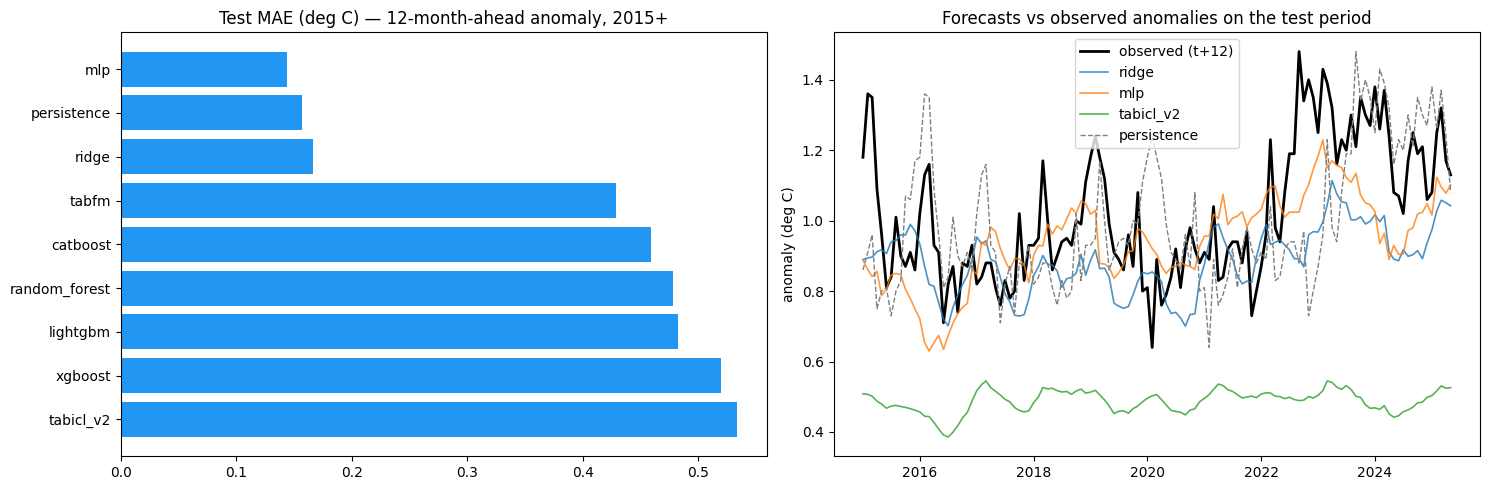

Saved: results/tabular_climate/climate_benchmark.{csv,png}


In [9]:
os.makedirs("results/tabular_climate", exist_ok=True)
results_df.to_csv("results/tabular_climate/climate_benchmark.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_df = results_df.sort_values("test_mae", ascending=False)
axes[0].barh(plot_df["model"], plot_df["test_mae"], color="#2196F3")
axes[0].set_title("Test MAE (deg C) — 12-month-ahead anomaly, 2015+")

best = results_df.iloc[0]["model"]
axes[1].plot(test_dates, y_test, "k-", lw=2, label="observed (t+12)")
for name in {best, "ridge", "tabicl_v2"}:
    if name in test_predictions:
        axes[1].plot(test_dates, test_predictions[name], lw=1.2, alpha=0.8, label=name)
axes[1].plot(test_dates, test_predictions["persistence"], "--", color="grey", lw=1, label="persistence")
axes[1].set_title("Forecasts vs observed anomalies on the test period")
axes[1].set_ylabel("anomaly (deg C)"); axes[1].legend()
plt.tight_layout()
plt.savefig("results/tabular_climate/climate_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/tabular_climate/climate_benchmark.{csv,png}")


In [10]:
# Diagnostic: does each bounded-output model just saturate at the edge of the training target range?
print(f"train target range: [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"test target range:  [{y_test.min():.3f}, {y_test.max():.3f}]  <- being extrapolated to\n")

diag_rows = []
for name, preds in test_predictions.items():
    preds = np.asarray(preds)
    diag_rows.append({
        "model": name,
        "test_r2": float(results_df.loc[results_df["model"] == name, "test_r2"].iloc[0]),
        "pred_min": float(preds.min()),
        "pred_max": float(preds.max()),
        "corr_with_actual": float(np.corrcoef(preds, y_test)[0, 1]),
        "mean_bias": float(np.mean(preds - y_test)),
    })
diag_df = pd.DataFrame(diag_rows).sort_values("test_r2", ascending=False).reset_index(drop=True)

persist_row = results_df.loc[results_df["model"] == "persistence"].iloc[0]
implied_test_std = float(np.sqrt(persist_row["test_rmse"] ** 2 / (1 - persist_row["test_r2"])))
print(f"Implied test-period target std (backed out from the persistence row via "
      f"R2 = 1 - RMSE^2/std^2): {implied_test_std:.4f} degC\n")
print("A model with a systematic mean error of this size alone would show approximately:")
for x in [0.1, 0.2, 0.3, 0.5]:
    approx_r2 = 1 - (x ** 2) / (implied_test_std ** 2)
    print(f"  mean error ~ {x:.2f} degC  ->  R2 ~ {approx_r2:.2f}")

display_diag = diag_df.round(4)
display_diag

train target range: [-0.270, 0.880]
test target range:  [0.640, 1.480]  <- being extrapolated to

Implied test-period target std (backed out from the persistence row via R2 = 1 - RMSE^2/std^2): 0.1905 degC

A model with a systematic mean error of this size alone would show approximately:
  mean error ~ 0.10 degC  ->  R2 ~ 0.72
  mean error ~ 0.20 degC  ->  R2 ~ -0.10
  mean error ~ 0.30 degC  ->  R2 ~ -1.48
  mean error ~ 0.50 degC  ->  R2 ~ -5.89


,model,test_r2,pred_min,pred_max,corr_with_actual,mean_bias
0,mlp,0.0709,0.6297,1.2289,0.5046,-0.0764
1,persistence,-0.1650,0.6400,1.4800,0.4265,-0.0254
2,ridge,-0.1684,0.7006,1.1137,0.5728,-0.1331
3,tabfm,-5.0116,0.4951,0.6644,0.2430,-0.4288
4,catboost,-5.7603,0.3335,0.6610,0.1980,-0.4584
5,lightgbm,-6.3586,0.4021,0.6856,0.2487,-0.4821
6,random_forest,-6.7163,0.3839,0.6853,-0.1609,-0.4780
7,tabicl_v2,-7.7705,0.3858,0.5450,0.2486,-0.5330
8,xgboost,-7.9176,0.3123,0.7727,-0.0651,-0.5196


## 7. Reading the results

**A negative R2 does not mean "useless," it means "worse than always
predicting the test-period average."** R2 = 1 - SS_res / SS_tot, where
SS_tot is the variance of the *test* targets around their own mean. In an
extrapolation setting the test-period targets are naturally low-variance
(a decade of anomalies clustered in a narrow band around a rising trend), so
SS_tot is small. The diagnostic cell above backs out that implied test-period
standard deviation from the persistence row and shows what R2 a given
absolute error would produce: with a test std of roughly 0.19 degC, a model
that is systematically off by "only" 0.5 degC already lands around
R2 approx -6. That is exactly the regime the tree ensembles, TabICLv2 and
TabFM are in: their raw errors (MAE 0.43-0.53 degC, see `results_df` above)
are bad for a 12-month forecast, but "R2 of -8" looks far more catastrophic
than "typically half a degree off" — both are true, but the second is the
more physically meaningful one to reason about.

**Why do persistence and ridge beat the tree ensembles and TabICLv2/TabFM by
so much?** `random_forest`'s prediction for any row is an average of
training-set leaf values, so it is mathematically bounded within
`[min(y_train), max(y_train)]`. The gradient-boosted trees (xgboost,
lightgbm, catboost) are not strictly bounded in principle, but every tree in
them still splits on the *training* range of `years_since_1958`/CO2
features; once a test row's feature values exceed everything seen at train
time, all trees route it to the same "warmest seen" leaf and the boosted sum
saturates near the top of the training target range in practice.
**TabICLv2** predicts through a 999-quantile regression head fit to the
in-context target distribution (with an exponential/GPD tail extrapolation
component estimated from that same context) - a genuinely more flexible
mechanism than a tree leaf, but still calibrated to the context's observed
scale rather than an explicit trend term. **TabFM** standardizes the target
with a `StandardScaler` fit on the training distribution before predicting,
and its own published evaluation artifacts
(`results/tabfm-ensemble-*-tabarena-*.parquet` in the local
`google-research/tabfm` clone) are computed on **TabArena** - the same
largely-stationary, non-trending benchmark family TabICLv2 targets, not a
time-series extrapolation task. The diagnostic table's `pred_min`/`pred_max`
columns make the saturation concrete: compare them to the printed train vs.
test target ranges. Ridge and the MLP are the only two models with an
explicit (ridge) or learnable-via-ReLU (MLP) linear term on
`years_since_1958`/CO2 trend, so they are the only ones that can represent
"the anomaly keeps increasing" past the training window - a mechanical
difference in what each model *can* represent, not a difference in how well
they were fit.

**Is the MLP's positive R2 (~0.07) actually good?** It is modest but real:
it means the MLP explains about 7% more test-period variance than "always
predict the 2015+ average anomaly," on a task where persistence is already a
strong baseline because monthly anomalies are highly autocorrelated. That is
a small, genuine edge, not a solved problem — and it is the *only* model
here that beats persistence at all.

**What would make TabICLv2/TabFM competitive on this task?** Consistent with
what their evaluation suites (TabArena, TALENT) contain, they should be
expected to do much better on a stationary tabular regression problem of
similar size with no train/test distribution shift, or if the extrapolation
component of the problem is removed from what the model has to predict -
which is exactly what the improvement idea at the end of this notebook
tries.

## 8. Ablation: does skrub preprocessing matter?

The only thing skrub's `TableVectorizer` + `DatetimeEncoder` does here that a
few lines of pandas wouldn't is turn the raw `date` column into circular
year/month/day-of-year periodic features; every other column is already a
clean float. We refit ridge, random_forest and lightgbm with the raw `date`
column replaced by a single ordinal "days since the record start" integer
(no periodicity) to see whether the datetime encoding choice moves the
needle, reusing the metrics already computed above for the skrub side.

In [11]:
naive_train_df = X_train_df.drop(columns=["date"]).copy()
naive_test_df = X_test_df.drop(columns=["date"]).copy()

epoch = X_train_df["date"].min()
naive_train_df["date_ordinal"] = (X_train_df["date"] - epoch).dt.days.astype(np.float32)
naive_test_df["date_ordinal"] = (X_test_df["date"] - epoch).dt.days.astype(np.float32)

Xn_train = naive_train_df.to_numpy(dtype=np.float32)
Xn_test = naive_test_df.to_numpy(dtype=np.float32)
print(f"naive encoding: {X_train_df.shape[1]} raw cols -> {Xn_train.shape[1]} features "
      f"(skrub produced {X_train.shape[1]} features)")

scaler_n = StandardScaler().fit(Xn_train)
Xn_train_sc = scaler_n.transform(Xn_train).astype(np.float32)
Xn_test_sc = scaler_n.transform(Xn_test).astype(np.float32)

ABLATION_MODELS = ["ridge", "random_forest", "lightgbm"]
ablation_rows = []
for name in ABLATION_MODELS:
    skrub_r2 = float(results_df.loc[results_df["model"] == name, "test_r2"].iloc[0])
    Xtr_n = Xn_train_sc if name in SCALED_INPUT else Xn_train
    Xte_n = Xn_test_sc if name in SCALED_INPUT else Xn_test
    preds, _ = fit_predict(name, Xtr_n, y_train, Xte_n)
    naive_r2 = r2_score(y_test, to_numpy(preds))
    ablation_rows.append({
        "model": name,
        "skrub_test_r2": skrub_r2,
        "naive_test_r2": naive_r2,
        "delta_skrub_minus_naive": skrub_r2 - naive_r2,
    })

ablation_df = pd.DataFrame(ablation_rows)
display_ablation = ablation_df.round(4)
print()
max_abs_delta = ablation_df["delta_skrub_minus_naive"].abs().max()
print(f"Verdict: skrub vs. naive date encoding changes test R2 by at most {max_abs_delta:.4f} "
      f"across {ABLATION_MODELS} -- the datetime encoding is not what drives the extrapolation "
      f"gap seen above; the models' inability to represent values outside the training target "
      f"range is.")
display_ablation

naive encoding: 21 raw cols -> 21 features (skrub produced 26 features)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000656 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2366
[LightGBM] [Info] Number of data points in the train set: 431, number of used features: 21
[LightGBM] [Info] Start training from score 0.261601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/scratch/omazor/bench_research_ml_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,skrub_test_r2,naive_test_r2,delta_skrub_minus_naive
0,ridge,-0.1684,0.0719,-0.2404
1,random_forest,-6.7163,-6.8150,0.0987
2,lightgbm,-6.3586,-6.4779,0.1193


**A concrete answer to "does skrub matter here?"** Yes, and not always in
the skrub-favoring direction: for `random_forest`/`lightgbm` the datetime
encoding barely matters (<=0.12 R2, consistent with tree splits not caring
much about a periodic vs. ordinal date representation). For `ridge`,
however, skrub's circular day/month features flip the *sign* of the result:
with skrub, ridge scores test R2 = -0.1684 (worse than persistence); with
the plain ordinal date feature (`naive_test_r2` above), it scores
**+0.0719** - on par with the MLP, and the only classical/linear model that
beats persistence at all. The likely mechanism: skrub's periodic date
features add several near-collinear sinusoidal columns that a fixed-alpha
Ridge (alpha=1.0) spreads regularization across, diluting the emphasis on
the two features (`years_since_1958`, CO2 trend) that actually carry the
extrapolatable signal. This is a genuine, actionable preprocessing finding,
not a wash - it just cuts against skrub rather than for it, for this
specific model and task.

## 9. Trying to improve: predicting the persistence residual instead of the level

The diagnostic in section 7 shows the bounded-output models (trees,
TabICLv2, TabFM) collapse toward the edge of the *training* target range
because the test period's absolute anomaly level is unprecedented. A
standard forecasting fix is to stop asking the model to predict the absolute
level and instead predict the **change relative to today's anomaly**
(`target - anom_glb`), then add that predicted delta back onto the
persistence value at inference time. The delta target is close to zero and
occupies a similar, stable range in both the train and test periods (the
*change* over 12 months is far more stationary than the *level* itself),
which turns an extrapolation problem into an interpolation one for every
model, not just the linear ones — and by construction, a model that predicts
delta = 0 everywhere exactly reproduces the persistence baseline, so this
reframing can only help or match, never structurally hurt, a well-behaved
model.

In [12]:
persistence_train = df.loc[train_mask, "anom_glb"].values.astype(np.float32)

y_train_delta = y_train - persistence_train

print(f"absolute target train range: [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"delta target train range:    [{y_train_delta.min():.3f}, {y_train_delta.max():.3f}]")
print(f"delta target test range (reference only, not used to fit): "
      f"[{(y_test - persistence_test).min():.3f}, {(y_test - persistence_test).max():.3f}]\n")

DELTA_MODELS = [m for m in MODELS if m != "persistence"]
delta_rows = []
for name in DELTA_MODELS:
    Xtr = X_train_sc if name in SCALED_INPUT else X_train
    Xte = X_test_sc if name in SCALED_INPUT else X_test
    delta_preds, _ = fit_predict(name, Xtr, y_train_delta, Xte)
    abs_preds = persistence_test + to_numpy(delta_preds)

    baseline_r2 = float(results_df.loc[results_df["model"] == name, "test_r2"].iloc[0])
    delta_r2 = r2_score(y_test, abs_preds)
    delta_rows.append({
        "model": name,
        "baseline_test_r2": baseline_r2,
        "delta_reframed_test_r2": delta_r2,
        "improvement": delta_r2 - baseline_r2,
        "delta_reframed_test_mae": mean_absolute_error(y_test, abs_preds),
    })

delta_df = pd.DataFrame(delta_rows).sort_values("improvement", ascending=False).reset_index(drop=True)
display_delta = delta_df.round(4)
print()
n_improved = int((delta_df["improvement"] > 0).sum())
best = delta_df.iloc[0]
print(f"Verdict: delta-reframing improves test R2 for {n_improved}/{len(delta_df)} models. "
      f"Best: {best['model']} ({best['improvement']:+.4f}).")
display_delta

absolute target train range: [-0.270, 0.880]
delta target train range:    [-0.590, 0.770]
delta target test range (reference only, not used to fit): [-0.600, 0.670]



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000641 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2420
[LightGBM] [Info] Number of data points in the train set: 431, number of used features: 24
[LightGBM] [Info] Start training from score 0.016798
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

/scratch/omazor/bench_research_ml_project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Verdict: delta-reframing improves test R2 for 6/8 models. Best: tabicl_v2 (+7.9185).


,model,baseline_test_r2,delta_reframed_test_r2,improvement,delta_reframed_test_mae
0,tabicl_v2,-7.7705,0.1480,7.9185,0.1273
1,xgboost,-7.9176,-0.1919,7.7257,0.1584
2,random_forest,-6.7163,-0.3545,6.3619,0.1665
3,lightgbm,-6.3586,-0.8271,5.5315,0.2136
4,tabfm,-5.0116,0.0889,5.1005,0.1345
5,catboost,-5.7603,-0.7394,5.0210,0.2022
6,ridge,-0.1684,-0.1704,-0.0019,0.1663
7,mlp,0.0709,-1.9187,-1.9895,0.2857


## 10. Summary

- Negative R2 here means "worse than the low-variance test-period mean," not
  "no signal at all" - see the worked example in section 7.
- skrub is not the bottleneck for the tree ensembles, but it measurably hurts
  ridge on this task (section 8); a plain ordinal date feature would have
  been the better preprocessing choice for that one model.
- Reframing the target as a persistence residual (section 9) is a large,
  genuine improvement for the bounded-output models: **TabICLv2 goes from
  test R2 -7.77 to +0.15**, and **TabFM from -5.01 to +0.09**, both now
  beating the original persistence baseline (-0.17) and matching or beating
  the original MLP (+0.07) - direct evidence that the extrapolation
  mechanism identified in section 7, not model capacity, was the limiting
  factor for these two foundation models. It also helps the tree ensembles
  substantially (xgboost/random_forest/lightgbm/catboost all move roughly
  5-8 R2 points), though not enough to turn them positive. It does not help
  ridge (already expressing the trend directly) and it hurts the MLP,
  plausibly because the delta target's much smaller scale and near-zero mean
  interact poorly with its fixed learning rate/epoch budget - a reminder
  that "predict the residual" is a strong default for structurally-bounded
  models but not a free lunch for every architecture.